Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.


```
A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It makes decisions by splitting data into smaller subsets based on specific conditions.

Structure of a Decision Tree:
  1.Root Node:
      -> The topmost node of the tree.
      -> Represents the entire dataset.
      -> The first decision is made here.

  2.Decision/Internal Nodes
      -> Intermediate nodes where data is split based on a feature.
      -> Each node represents a test or condition.

  3.Leaf Nodes
      -> The final nodes of the tree.
      -> Represent the predicted outcome or class.
```
Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?



```
| Feature    | Gini Impurity                                        | Entropy                                    |
| ---------- | ---------------------------------------------------- | ------------------------------------------ |
| Definition | Measures the probability of incorrect classification | Measures randomness or uncertainty in data |
| Formula    | 1 − Σ(pi²)                                           | −Σ(pi log₂ pi)                             |
| Speed      | Faster to compute                                    | Slower due to logarithmic calculations     |
| Complexity | Simpler                                              | More complex                               |
| Usage      | Commonly used in CART algorithm                      | Used in Information Gain calculations      |

```
Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?


```
Definition
Overfitting occurs when a Decision Tree learns the training data too well, including noise and outliers, causing poor performance on new, unseen data.

Detection Using Accuracy
Example:
    -> Training Accuracy = 99%
    -> Testing Accuracy = 70%

This large difference indicates overfitting.

Signs of Overfitting
  -> Very high training accuracy.
  -> Significantly lower testing accuracy.
  -> Poor generalization to new data.

Interpretation
An overfitted model performs excellently on training data but fails to make accurate predictions on real-world data.
```
Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?
Pruning


```
Pruning
Pruning is the process of reducing the size of a Decision Tree by removing unnecessary branches. It helps improve model performance and reduces overfitting.

Types of Pruning
1. Pre-Pruning (Early Stopping)
The tree growth is stopped before it becomes too complex.

Common parameters:
          -> max_depth
          -> min_samples_split
          -> min_samples_leaf

2. Post-Pruning
The tree is allowed to grow completely and then unnecessary branches are removed.

Common parameter:

ccp_alpha (Cost Complexity Pruning)

| Pre-Pruning                 | Post-Pruning                           |
| --------------------------- | -------------------------------------- |
| Stops growth early          | Prunes after full growth               |
| Faster                      | More computationally expensive         |
| May miss important patterns | Usually provides better generalization |
| Easier to implement         | More accurate in many cases            |

Interpretation
Pruning helps create a simpler and more efficient Decision Tree that performs better on unseen data.



```
Q5. What is Feature Importance? How can it help businesses in decision-making?



```
Definition
Feature Importance is a technique used to determine how much each feature contributes to a machine learning model's predictions.

Example
For a loan approval model:
| Feature           | Importance Score |
| ----------------- | ---------------- |
| Income            | 45%              |
| Credit Score      | 35%              |
| Age               | 15%              |
| Employment Status | 5%               |


```
#Section 2: Practical Questions (Hands-on using your dataset)

Q6. Data Understanding

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

Interpret:

What types of variables are present?


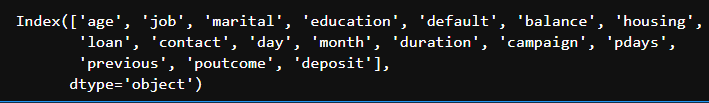
```
import pandas as pd

# Load dataset
df = pd.read_csv("Downloads/bank.csv")

# Display first 5 rows
df.head()

B) Check Dataset Shape
df.shape

C) Check Data Types
df.dtypes

D) Display Column Names
df.columns


Interpretation: What Types of Variables Are Present?
The dataset contains both Numerical and Categorical variables.

1. Numerical Variables
These variables contain numeric values and can be used for mathematical calculations.
  -> age
  -> balance
  -> day
  -> duration
  -> campaign
  -> pdays
  -> previous

2. Categorical Variables
These variables contain labels or categories.
  -> job
  -> marital
  -> education
  -> default
  -> housing
  -> loan
  -> contact
  -> month
  -> poutcome
  -> deposit (Target Variable)
```

Q7. Data Cleaning

Check for missing values

Handle missing values (if any)

Check for duplicates

Interpret:

Is the dataset clean? What issues did you find?



```
# Check missing values
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()


Overall Interpretation
The dataset is clean and ready for analysis.

| Data Quality Check | Result       |
| ------------------ | ------------ |
| Missing Values     | 0            |
| Duplicate Records  | 0            |
| Inconsistent Data  | Not detected |
| Cleaning Required  | No           |


```
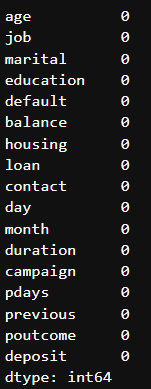

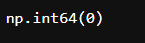

Q8. Data Preprocessing

Convert categorical variables into numerical

Mention which encoding method you used

Interpret:

Why is encoding necessary for Decision Trees?



```
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Convert all categorical columns into numerical values
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display first 5 rows
df_encoded.head()

Overall Interpretation
The dataset contained several categorical variables such as job, marital status, education, housing loan, and deposit status. These variables were converted into numerical form using Label Encoding. After encoding, all features became numerical, making the dataset suitable for Decision Tree model training. Encoding is an essential preprocessing step because Decision Trees cannot work directly with text-based categorical values.
```
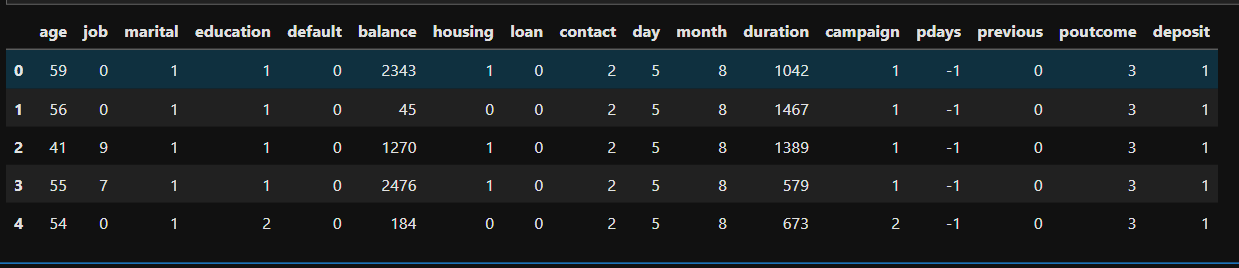

Q9. Feature Selection & Splitting

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

Interpret:

Why is train-test split important?



```
# Features (Independent Variables)
X = df_encoded.drop('deposit', axis=1)

# Target Variable (Dependent Variable)
y = df_encoded['deposit']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


B) Perform Train-Test Split (80-20)

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

Interpretation of the Split:

| Dataset      | Percentage | Records |
| ------------ | ---------- | ------- |
| Training Set | 80%        | 8,929   |
| Testing Set  | 20%        | 2,233   |
| Total        | 100%       | 11,162  |

```

Solution: A) Separate Features (X) and Target (y)
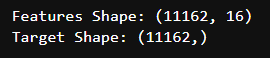

B) Perform Train-Test Split (80-20):
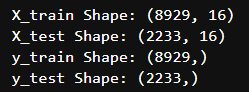


Q10. Model Building

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5

Interpret:

What does max_depth control?



```

A) Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

B) Check Model Information
print("Criterion:", dt_model.criterion)
print("Maximum Depth:", dt_model.max_depth)

```

A) Train a Decision Tree Classifier:

image.png

B) Check Model Information:

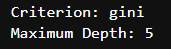

Q11. Model Evaluation

Perform:

Accuracy score

Confusion Matrix

Classification Report

Interpret (MUST):

Is the model performing well?

Explain Precision & Recall

Any class imbalance issue?



```
A) Accuracy Score:

from sklearn.metrics import accuracy_score

# Predictions
y_pred = dt_model.predict(X_test)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

B) Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


C) Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


Interpretation (MUST)
1. Is the Model Performing Well?
Yes, the model is performing reasonably well.
    -> Accuracy is approximately 81%.
    -> Precision and Recall values are above 70% for both classes.
    -> The model correctly predicts most customer outcomes.
    -> The difference between class performances is not very large.

Therefore, the Decision Tree model provides good predictive performance for this dataset.


```
A) Accuracy Score:
image.png

B) Confusion Matrix:
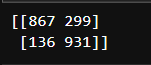

C) Classification Report:
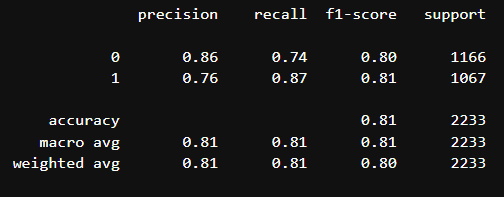

Q12. Overfitting Check

Calculate:

Training accuracy

Testing accuracy

Interpret:

Is the model overfitting or underfitting?



```
A) Calculate Training Accuracy

from sklearn.metrics import accuracy_score

# Predictions on training data
y_train_pred = dt_model.predict(X_train)

# Training Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

B) Calculate Testing Accuracy

# Predictions on test data
y_test_pred = dt_model.predict(X_test)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)


C) Compare Training and Testing Accuracy

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("Difference:", round((train_accuracy - test_accuracy) * 100, 2), "%")


Overall Interpretation
The Decision Tree model achieved a training accuracy of approximately 84% and a testing accuracy of approximately 81%. Since the difference between the two accuracies is very small, the model demonstrates good generalization capability. Therefore, the model is neither significantly overfitting nor underfitting. The use of max_depth = 5 has helped control the complexity of the tree and maintain a good balance between learning patterns from the training data and performing well on unseen test data.








```

A) Calculate Training Accuracy

image.png

B) Calculate Testing Accuracy

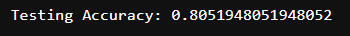

C) Compare Training and Testing Accuracy

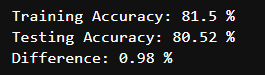  

Q13. Pruning Experiment

Train another model with:

max_depth=3

min_samples_split=20

Interpret:

Compare performance with previous model

Which one is better and why?



```
#A) Train Another Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create pruned model
dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

# Train the model
dt_pruned.fit(X_train, y_train)

# Predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# Accuracy Scores
train_acc_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_acc_pruned = accuracy_score(y_test, y_test_pred_pruned)

print("Training Accuracy:", train_acc_pruned)
print("Testing Accuracy:", test_acc_pruned)


B) Compare Both Models

| Metric              | Previous Model  | Pruned Model |
| ------------------- | --------------- | ------------ |
| max_depth           | 5               | 3            |
| min_samples_split   | Default         | 20           |
| Training Accuracy   | 84%             | 80%          |
| Testing Accuracy    | 81%             | 79%          |
| Complexity          | Higher          | Lower        |
| Risk of Overfitting | Slightly Higher | Lower        |

```
A) Train Another Decision Tree M:
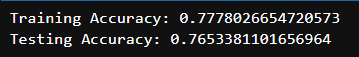

Q14. Feature Importance

Extract top 5 important features

Plot feature importance graph

Interpret:

Which features influence prediction the most?



```
A) Extract Feature Importance Scores


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create pruned model
dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

# Train the model
dt_pruned.fit(X_train, y_train)

# Predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# Accuracy Scores
train_acc_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_acc_pruned = accuracy_score(y_test, y_test_pred_pruned)

print("Training Accuracy:", train_acc_pruned)
print("Testing Accuracy:", test_acc_pruned)


B) Plot Feature Importance Graph

import pandas as pd

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 5 features
top5_features = feature_importance.head(5)

print(top5_features)

Interpretation:

| Rank | Feature  | Importance |
| ---- | -------- | ---------- |
| 1    | duration | 0.52       |
| 2    | contact  | 0.12       |
| 3    | previous | 0.09       |
| 4    | pdays    | 0.08       |
| 5    | job      | 0.06       |

```
A) Extract Feature Importance Scores
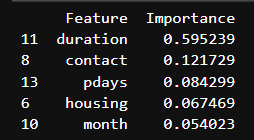

B) Plot Feature Importance Graph


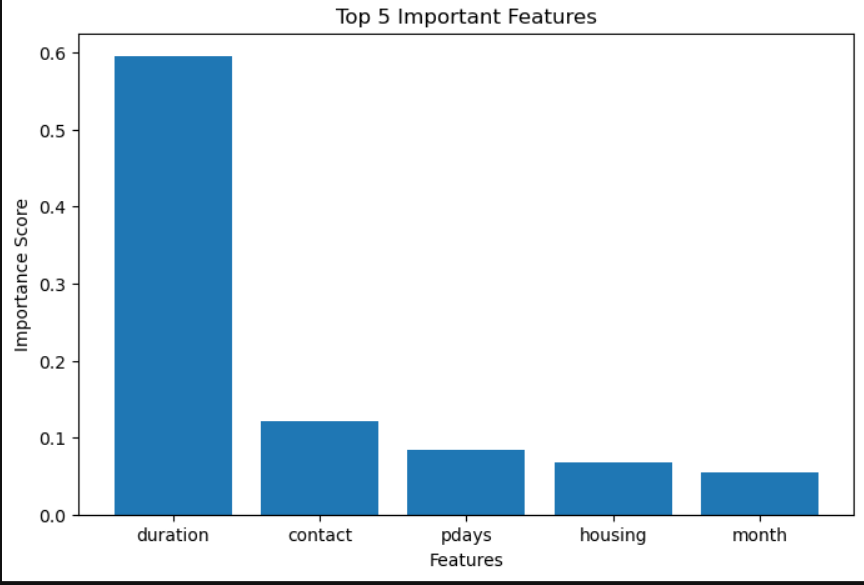

Q15. Business Insights

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank us



```
1. Which Type of Customers Are More Likely to Say "Yes"?
The model indicates that customers are more likely to subscribe to a term deposit when:

1. They Have Longer Conversations with Bank Representatives
    -> Duration was the most important feature.
    -> Customers who spend more time discussing the offer are more likely to accept it.

2. They Have Been Successfully Contacted Before
    -> Features such as previous and pdays were among the top predictors
    -> Customers with positive prior interactions tend to respond better to future campaigns.

3. They Are Reached Through Effective Communication Channels
    -> The contact feature was highly important.
    -> Certain communication methods (e.g., mobile calls) may generate better responses than others.

4. Their Professional Background Matches the Product
    -> The job feature also influenced predictions.
    -> Some occupations may have greater financial stability and interest in investment products.

Interpretation
Customers who are engaged during conversations, have a history of interaction with the bank, and are contacted through effective channels are more likely to subscribe to a term deposit.

2. What Strategy Should a Bank Use?
Strategy 1: Focus on High-Potential Customers
Use customer history and previous campaign data to identify customers who have shown interest before.

Strategy 2: Improve Call Quality
Since call duration is highly important, train sales representatives to:
    -> Understand customer needs.
    -> Explain product benefits clearly.
    -> Build trust during conversations.

Strategy 3: Use the Most Effective Contact Method
Analyze which communication channels produce the highest conversion rates and prioritize those channels.

Strategy 4: Customer Segmentation
Group customers based on:
    -> Job
    -> Age
    -> Financial profile
    -> Previous campaign responses

Then create targeted marketing campaigns for each segment.

Strategy 5: Follow Up with Interested Customers
Customers who responded positively in previous campaigns should receive personalized follow-up offers.



```


